In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [43]:
RED_COLOUR = [255, 0, 0]
GREEN_COLOUR = (0,255,0)

## 1. Loads a grayscale image

In [24]:
IMAGE_PATH = "giraffes.jpg"
IMAGE_GRAY = cv2.imread(IMAGE_PATH, 0)

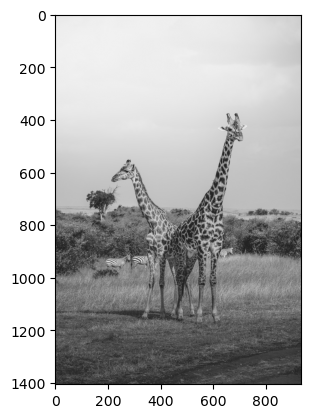

In [25]:
plt.imshow(IMAGE_GRAY, cmap='gray')

## 2.Runs Canny
with user-settable `low_thresh`, `high_thresh`, and `optional Gaussianblur σ`;

### a) Without blur

In [26]:
THRESH_1, THRESH_2 = 127, 127

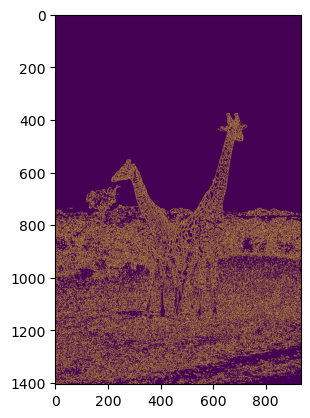

In [27]:
edges = cv2.Canny(image=IMAGE_GRAY,
                  threshold1=THRESH_1,
                  threshold2=THRESH_2)

plt.imshow(edges)

### b) With blur

In [28]:
THRESH_1, THRESH_2 = 127, 127
BLUR_K_SIZE        = (5, 5)

In [29]:
BLURRED_IMAGE = cv2.GaussianBlur(IMAGE_GRAY, BLUR_K_SIZE, 0)

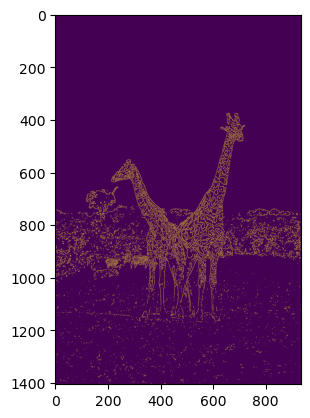

In [30]:
edges = cv2.Canny(image=BLURRED_IMAGE,
                  threshold1=THRESH_1,
                  threshold2=THRESH_2)

plt.imshow(edges)

## 3. Detects corners with cv2.goodFeaturesToTrack (Shi–Tomasi)
using tunable `maxCorners`, `qualityLevel`, and `minDistance`;

In [31]:
IMAGE_RGB = cv2.cvtColor(cv2.imread(IMAGE_PATH), cv2.COLOR_BGR2RGB)

In [32]:
QUALITY_LEVEL = 0.04
MAX_CORNERS = 100
MIN_DISTANCE = 10.0

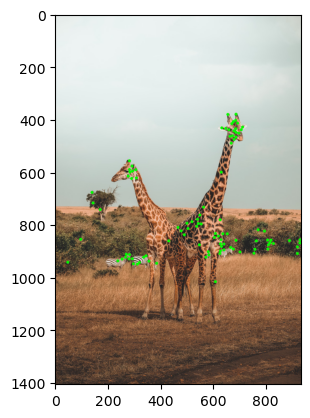

In [44]:
corners = cv2.goodFeaturesToTrack(IMAGE_GRAY,
                                  maxCorners = MAX_CORNERS,
                                  qualityLevel = QUALITY_LEVEL,
                                  minDistance = MIN_DISTANCE,
                                  blockSize = 10)
corners = np.int32(corners)

image_rgb_copy = IMAGE_RGB.copy()
for i in corners:
    x,y = i.ravel()
    cv2.circle(image_rgb_copy,(x,y),3,GREEN_COLOUR,3)

plt.imshow(image_rgb_copy)

## 4. Overlays edges (binary mask) and corner markers 
on the original image in distinct colors and saves two images: edges.png and corners.png;

In [ ]:
# Create copies for overlaying edges and corners
image_edges = IMAGE_RGB.copy()
image_corners = IMAGE_RGB.copy()

# Ensure we have a binary edge mask from earlier (use the last 'edges' variable)
# If 'edges' came from a blurred run, it's already defined above; otherwise recompute
try:
    edges_mask = edges.copy()
except NameError:
    # Recompute edges from IMAGE_GRAY with default thresholds if needed
    edges_mask = cv2.Canny(image=IMAGE_GRAY, threshold1=THRESH_1, threshold2=THRESH_2)

# Draw edges in red on image_edges: edges_mask is single-channel 0/255
# Where edges_mask > 0, set pixel to RED_COLOUR (RGB)
edge_positions = edges_mask > 0
image_edges[edge_positions] = RED_COLOUR

# Save edges image: convert from RGB (matplotlib-friendly) to BGR for OpenCV write
edges_bgr = cv2.cvtColor(image_edges, cv2.COLOR_RGB2BGR)
cv2.imwrite('edges.png', edges_bgr)

# Draw Shi-Tomasi corners in red on image_corners
# 'corners' variable should exist from the goodFeaturesToTrack call above
try:
    corners_iter = corners
except NameError:
    corners_iter = cv2.goodFeaturesToTrack(IMAGE_GRAY, maxCorners=MAX_CORNERS, qualityLevel=QUALITY_LEVEL, minDistance=MIN_DISTANCE, blockSize=10)
    corners_iter = np.int32(corners_iter)

# Draw small filled circles in red at each corner location
for c in corners_iter:
    x, y = c.ravel()
    # set RGB pixel to red for a small neighborhood so it's visible
    rr = slice(max(0, y-2), min(image_corners.shape[0], y+3))
    cc = slice(max(0, x-2), min(image_corners.shape[1], x+3))
    image_corners[rr, cc] = RED_COLOUR

# Save corners image (convert to BGR for cv2.imwrite)
corners_bgr = cv2.cvtColor(image_corners, cv2.COLOR_RGB2BGR)
cv2.imwrite('corners.png', corners_bgr)

# Display the two saved overlays side-by-side
fig, axs = plt.subplots(1,3, figsize=(15,6))
axs[0].imshow(IMAGE_RGB)
axs[0].set_title('Original RGB')
axs[0].axis('off')
axs[1].imshow(image_edges)
axs[1].set_title('Edges in Red')
axs[1].axis('off')
axs[2].imshow(image_corners)
axs[2].set_title('Corners in Red')
axs[2].axis('off')
plt.show()